In [1]:
import torch
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools

from src.utils.DataGenerator import DataGenerator
from src.methods.AALS import AALS
from src.methods.AABernoulli import Bernoulli_Archetypal_Analysis
from src.methods.PCHABer import PCHABer

from src.visualisations.PlotLossArc import plot_loss_arc
from src.visualisations.PlotNMIStability import plot_nmi_stability

from src.utils.NMI import calcNMI


# Initialise some synthetic data


In [2]:
n_samples, n_features, n_arc = 1000, 100, 5
sparsity = 0.4
alpha = 1 
seed = 42 
noise = 0.1 

X= DataGenerator(n_samples, n_features, n_arc, 'Bernoulli', sparsity, alpha, seed, noise,'torch').CreateData()

# X here is features x samples 

# Run for different hyper parameters


In [4]:
# Find optimal number of archetypes (True = 5)
n_arc_list = [2,3,4,5,6,7,8,9,10]
Losses = np.zeros((len(n_arc_list),10))
Ss = np.zeros((len(n_arc_list),10),dtype=object)

for n in tqdm(n_arc_list):
    for i in range(10):

        C,S,L = Bernoulli_Archetypal_Analysis(X, n)
        Losses[n_arc_list.index(n),i] = L[-1]
        Ss[n_arc_list.index(n),i] = S


100%|██████████| 9/9 [08:20<00:00, 55.61s/it]


ValueError: Incorrect use of keyword argument 'fontsize'. Keyword arguments other than 'minor' modify the text labels and can only be used if 'labels' are passed as well.

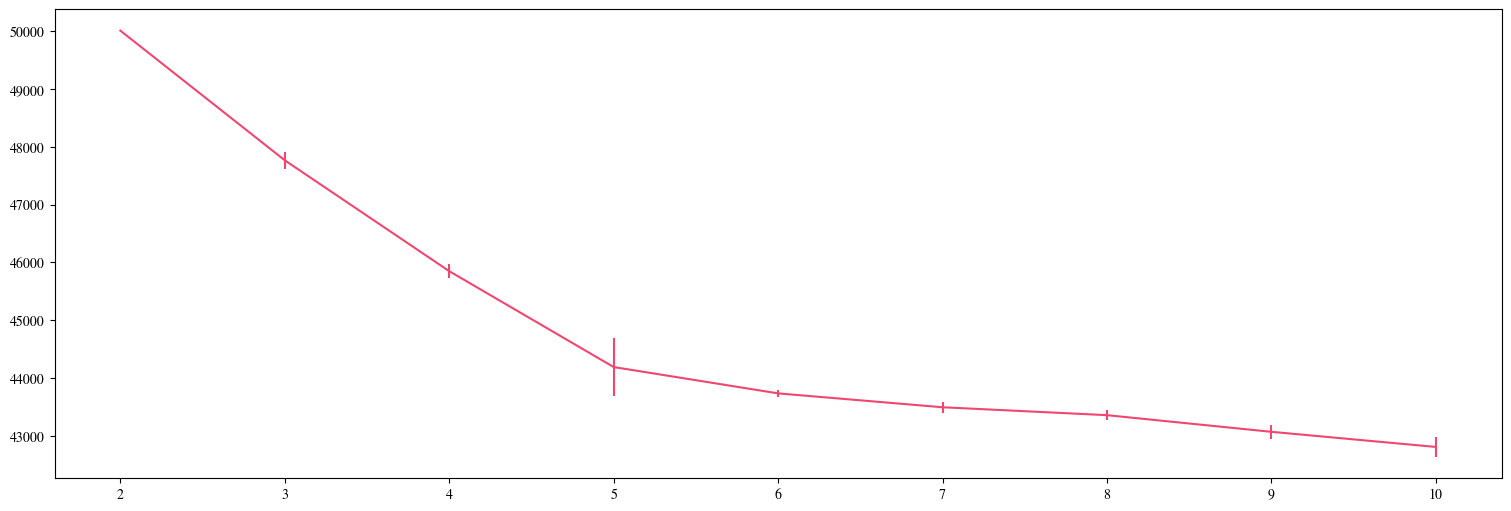

In [6]:

colors = ["#EF476F",  "#06D6A0", "#FFD166", "#073B4C", "#118AB2", "#FF6B6B", "#C8A2C8"]


plot_loss_arc(Losses,n_arc_list,i,colors[0],'Synthetic', 'Bernoulli', savedir = None)

In [5]:
test = itertools.combinations(range(10), 2)
t = list(test)
calcIDX = np.array(t)

NMI = np.zeros((len(n_arc_list),len(calcIDX)))

for n in tqdm(n_arc_list):
    for j in range(len(calcIDX)):

        S1 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,0]])
        S2 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,1]])


        NMI[n_arc_list.index(n),j] = calcNMI(S1,S2)



100%|██████████| 9/9 [00:00<00:00, 92.78it/s]


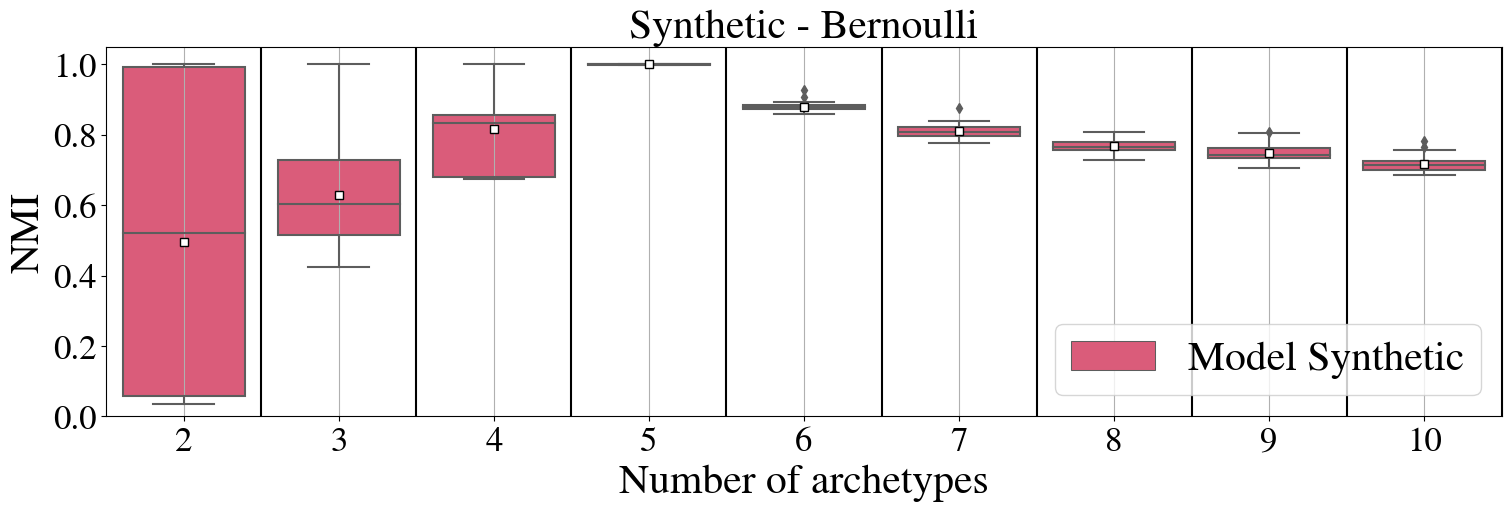

In [6]:
plot_nmi_stability(NMI,n_arc_list, 'Synthetic','Bernoulli',colors)

# Gaussian Data: 

In [8]:
X= DataGenerator(n_samples, n_features, n_arc, 'Gaussian', sparsity, alpha, seed, noise,'torch').CreateData()
print(X.shape)


torch.Size([100, 1000])


In [20]:
# Load MNIST dataset
from torchvision import datasets, transforms

# Download and load MNIST
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Convert to numpy array and reshape
# Get all images and flatten them
X_mnist = mnist_train.data.numpy().reshape(len(mnist_train.data), -1).T  # Shape: (784, 60000)

# Normalize to [0, 1] range
X_mnist = X_mnist / 255.0

# Convert to torch tensor with double precision to match AALS expectations
X = torch.from_numpy(X_mnist).double()

print(f"MNIST data shape: {X.shape}")  # Should be (784, 60000)
print(f"Data type: {X.dtype}")
print(f"Data range: [{X.min():.2f}, {X.max():.2f}]")


MNIST data shape: torch.Size([784, 60000])
Data type: torch.float64
Data range: [0.00, 1.00]
Data range: [0.00, 1.00]


In [13]:
# reduce dataset to 100 samples for quicker testing
X = X[:, :100]

In [21]:
# Find optimal number of archetypes (True = 5)
n_arc_list = [f for f in range(2,30)]
Losses = np.zeros((len(n_arc_list),10))
Ss = np.zeros((len(n_arc_list),10),dtype=object)

for n in tqdm(n_arc_list):
    for i in range(10):

        C,S,L,EV = AALS(X, n)
        Losses[n_arc_list.index(n),i] = L[-1]
        Ss[n_arc_list.index(n),i] = S


  0%|          | 0/28 [04:44<?, ?it/s]



KeyboardInterrupt: 

ValueError: Incorrect use of keyword argument 'fontsize'. Keyword arguments other than 'minor' modify the text labels and can only be used if 'labels' are passed as well.

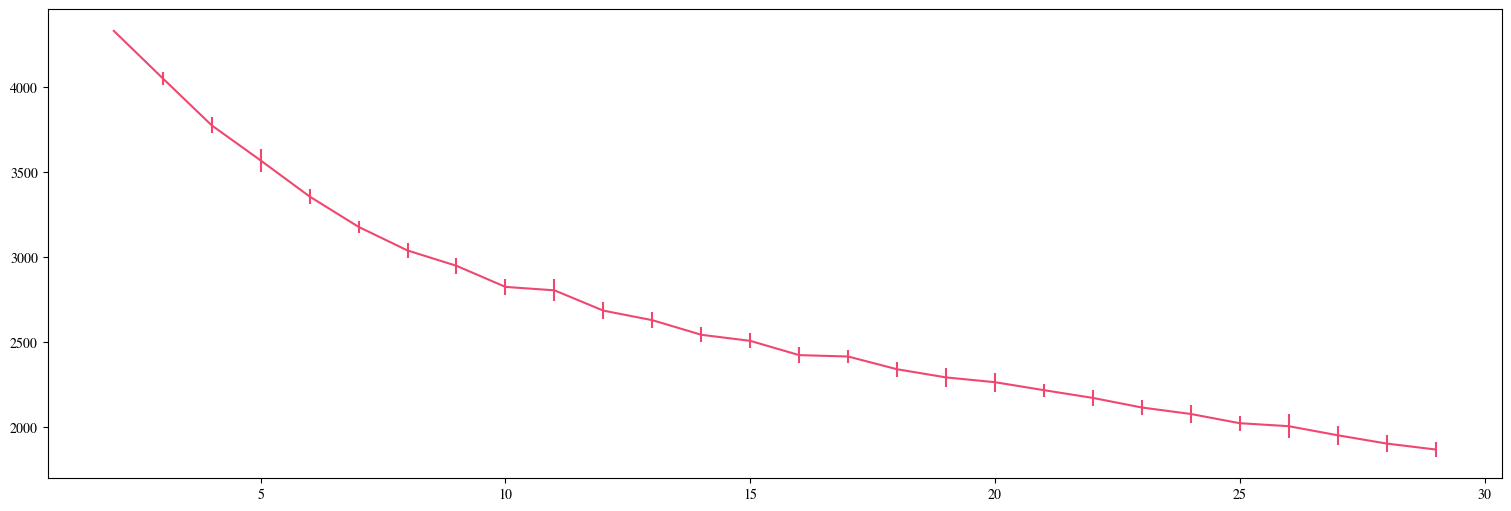

In [17]:

plot_loss_arc(Losses,n_arc_list,i,colors[0],'Synthetic', 'Gaussian', savedir = None)

In [18]:
test = itertools.combinations(range(10), 2)
t = list(test)
calcIDX = np.array(t)

NMI = np.zeros((len(n_arc_list),len(calcIDX)))

for n in tqdm(n_arc_list):
    for j in range(len(calcIDX)):

        S1 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,0]])
        S2 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,1]])


        NMI[n_arc_list.index(n),j] = calcNMI(S1,S2)


100%|██████████| 28/28 [00:00<00:00, 89.55it/s]


e:\Master\Semester2\Deep Learning\Project\Archetypal-Analysis-For-Binary-Data\Python\src\visualisations\PlotNMIStability.py:16: UserWarning: The palette list has more values (7) than needed (1), which may not be intended.
  ax = sns.boxplot(x='Archetypes', y="NMI", hue="Method", showmeans=True, data=df,palette=colors,meanprops={"marker": "s", "markerfacecolor": "white", "markeredgecolor": "black"})


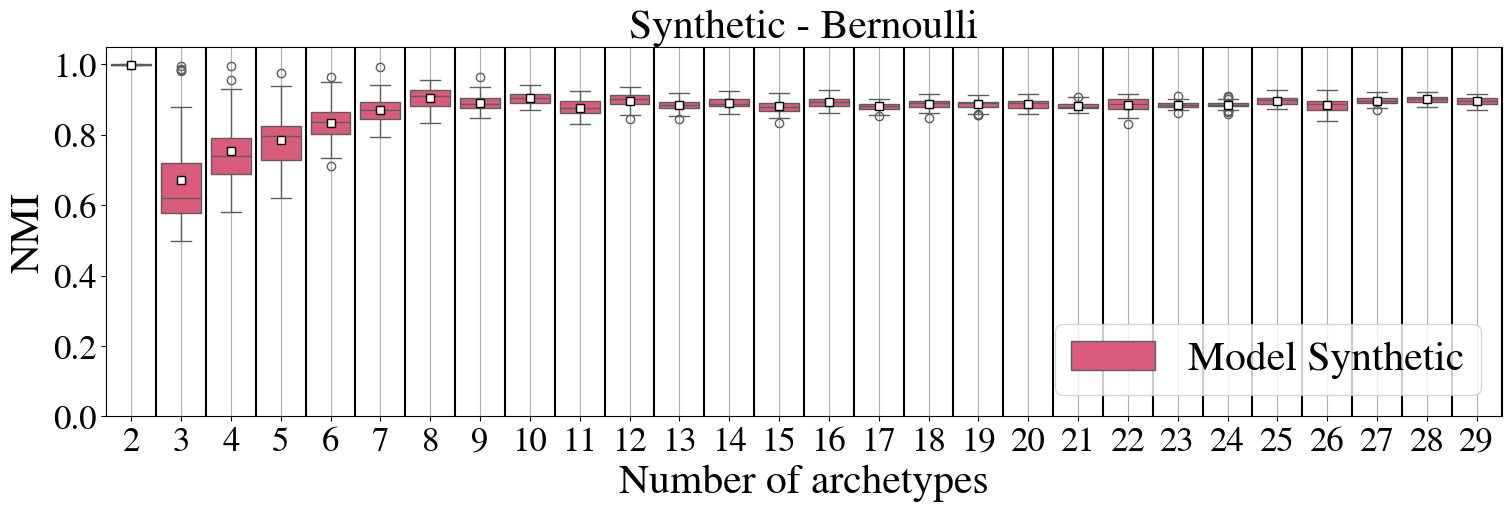

In [19]:
plot_nmi_stability(NMI,n_arc_list, 'Synthetic','Bernoulli',colors)